In [ ]:
pip install keras-tuner

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 KB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Trans-Ubiquitination-Colab/BraveHeart

/content/drive/MyDrive/Trans-Ubiquitination-Colab/BraveHeart


In [ ]:
import numpy as np
x = np.load("yeast_suc_embeddings_X.npy")

In [ ]:
x.shape

(1620, 17664)

In [ ]:
y = np.load("yeast_suc_embeddings_Y.npy")

In [ ]:
y.shape

(1620,)

In [ ]:
import pandas as pd
x_dataframe = pd.DataFrame(x)

In [ ]:
x_dataframe

,0,1,2,3,4,5,6,7,8,9,...,17654,17655,17656,17657,17658,17659,17660,17661,17662,17663
0,-0.737948,-0.205775,-0.229596,-0.013059,-0.284499,0.018241,0.516685,0.341904,-0.190822,-0.612394,...,0.071960,0.027943,-0.170091,-0.220462,0.015464,-0.058835,-0.029693,0.067589,-0.244859,-0.073423
1,-0.153332,1.307280,-1.217498,-1.522796,-1.098675,0.172906,1.190570,-0.176398,-0.338374,-0.254028,...,0.079248,0.140771,0.018500,0.070564,0.482746,-0.201055,-0.286591,0.146512,-0.224151,0.495097
2,-0.953944,-0.233599,-0.205253,-0.079951,-0.414902,-0.000808,0.497341,0.285406,-0.324682,-0.265562,...,0.036540,0.012123,-0.163431,-0.244867,0.060408,-0.081489,-0.037540,0.070487,-0.225933,-0.049318
3,0.132364,1.045121,-1.001368,-1.108606,-1.034043,0.022368,1.358162,-0.086003,0.393144,-0.446976,...,0.077261,0.219830,-0.085698,0.393052,0.694359,-0.410512,-0.495872,0.102294,-0.052407,0.789172
4,-0.802931,-0.188292,-0.149052,-0.045360,-0.268330,-0.065373,0.597418,0.199124,-0.229645,-0.422060,...,0.046852,0.005260,-0.176972,-0.261728,0.055626,-0.078467,0.002065,0.039186,-0.274152,-0.033297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,0.175400,1.054524,-1.039594,-1.552206,-0.984096,-0.023997,1.137135,-0.548124,-0.137695,-0.393581,...,0.013126,0.253074,0.091317,-0.007520,0.940147,-0.332864,-0.395750,0.056708,-0.317219,0.755296
1616,-0.943163,-0.179347,-0.132250,0.003773,-0.434947,0.039781,0.599023,0.211688,-0.285550,-0.366824,...,0.058333,0.002528,-0.178003,-0.268471,0.029470,-0.041514,-0.049059,0.084164,-0.262781,-0.078218
1617,-0.218697,0.696362,-0.968931,-1.452132,-1.004525,0.056526,1.012427,-0.448562,-0.236128,0.232434,...,-0.174326,0.073207,0.137304,0.277487,0.635334,-0.330347,-0.488085,0.287653,-0.666133,0.866838
1618,-0.652581,-0.244805,-0.229025,0.182967,-0.508017,0.027382,0.461388,0.232103,-0.162400,-0.466331,...,0.087228,0.022954,-0.157861,-0.240154,0.026478,-0.065984,-0.015726,0.076851,-0.201569,-0.069672


In [ ]:
y

array([1, 1, 1, ..., 0, 0, 0])

# 1D CNN

In [ ]:
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Activation, Conv1D, ZeroPadding1D, MaxPooling1D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
import tensorflow as tf
from tensorflow import keras
from kerastuner import RandomSearch
from tensorflow.keras import utils
from sklearn.metrics import precision_recall_curve

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state = 42)
xval, xtest, yval, ytest = train_test_split(xtest, ytest, test_size = 0.5)

def CNN_1D():
    model = Sequential()

    # layer 1
    model.add(Conv1D(8, 3, input_shape=(23*768, 1), activation="relu"))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.1))

    # layer 2
    model.add(Conv1D(16, 3, activation="relu"))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.2))

    # Flattening Layer:
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))

    # Last Layer:
    model.add(Dense(2, activation="softmax"))
    model.compile(loss="categorical_crossentropy", optimizer=Adam(lr = 0.00005),
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

model1 = CNN_1D()

a = np.asarray(xtrain).reshape(len(np.asarray(xtrain)),23*768,1)

history1_ = model1.fit(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),23*768,1), utils.to_categorical(ytrain,2),
                    validation_data=(np.asarray(xval).reshape(len(np.asarray(xval)),23*768,1), utils.to_categorical(yval,2)),
                    epochs=50, batch_size=20, verbose=1)  

score = model1.evaluate(np.asarray(xtest).reshape(len(np.asarray(xtest)),23*768,1), utils.to_categorical(ytest,2), verbose=1)
print("categorical_crossentropy loss, Accuracy, Precision, Recall scores:", score)


plt.plot(history1_.history["accuracy"])
plt.plot(history1_.history["val_accuracy"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("1D CNN Model Accuracy", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()
plt.figure(figsize=(10,10), dpi = 600)

plt.plot(history1_.history["loss"])
plt.plot(history1_.history["val_loss"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Loss", fontsize = 15)
plt.title("1D CNN Model Loss", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()

print(model1.summary())

import seaborn as sns
from sklearn.metrics import confusion_matrix
cnn_predictions1 = model1.predict(xtest)
bert2_probs_cnn1 = cnn_predictions1[:,1]
cnn_predictions1 = np.argmax(cnn_predictions1, axis = 1)
confusion_matrix = confusion_matrix(ytest, cnn_predictions1)
sns.heatmap(confusion_matrix, annot = True, fmt = "d", cbar = False)
plt.title("BERT + 1D CNN Confusion Matrix", fontsize = 20)

plt.show()

from sklearn.metrics import roc_curve
fpr_keras_bert_cnn1_hyp, tpr_keras_bert_cnn1_hyp, _ = roc_curve(ytest, bert2_probs_cnn1)

from sklearn.metrics import auc
auc_keras_bert_cnn1_hyp = auc(fpr_keras_bert_cnn1_hyp, tpr_keras_bert_cnn1_hyp)
print("AUC Score", auc_keras_bert_cnn1_hyp)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras_bert_cnn1_hyp, tpr_keras_bert_cnn1_hyp, label="BERT + 1D-CNN: {:.3f}".format(auc_keras_bert_cnn1_hyp))
plt.xlabel("False positive rate", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("ROC curve for BERT + 1D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()

print("----------------------------------------------")


precision_bert2_cnn1, recall_bert2_cnn1, _ = precision_recall_curve(ytest, bert2_probs_cnn1)
auc_precision_recall_bert2_cnn1 = auc(recall_bert2_cnn1, precision_bert2_cnn1)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(recall_bert2_cnn1, precision_bert2_cnn1, label="BERT + 1D-CNN: {:.3f}".format(auc_precision_recall_bert2_cnn1))
plt.xlabel("Recall", fontsize = 15)
plt.ylabel("Precision", fontsize = 15)
plt.title("PR curve for BERT + 1D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()

print("----------------------------------------------")

# 2D CNN Without Tuner

In [ ]:
################ Without tuner ########################
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Activation, MaxPooling1D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
import tensorflow as tf
from tensorflow import keras
from kerastuner import RandomSearch
from tensorflow.keras import utils
from sklearn.metrics import precision_recall_curve



xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state=None, shuffle=True)
xval, xtest, yval, ytest = train_test_split(xtest, ytest, test_size = 0.5, random_state=None, shuffle=True)

def CNN_2D():
    model = Sequential()

    # layer 1
    model.add(Conv2D(8, 4,4, input_shape=(768, 23, 1), activation="relu")) 
    model.add(MaxPooling2D(2))
    model.add(Dropout(0.1))


    # layer 2
    model.add(Conv2D(16, 2, 2, activation="relu"))
    #model.add(MaxPooling2D(2))
    model.add(Dropout(0.2))

    

    # Flattening Layer:
    model.add(Flatten())
    model.add(Dense(48, activation="relu"))
    model.add(Dense(32, activation="relu"))

    # Last Layer:
    model.add(Dense(2, activation="softmax"))
    model.compile(loss="binary_crossentropy", optimizer=Adam(lr = 0.0002),
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

model2 = CNN_2D()

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0.0008, patience=40,  verbose=1, mode='min')

history2_ = model2.fit(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),768,23,1), utils.to_categorical(ytrain,2),
                    validation_data=(np.asarray(xval).reshape(len(np.asarray(xval)),768,23,1), utils.to_categorical(yval,2)), callbacks = [stop_early],
                    epochs=200, batch_size=150, verbose=1)


Epoch 1/200


/usr/local/lib/python3.8/dist-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


9/9 [==============================] - 1s 48ms/step - loss: 0.7403 - accuracy: 0.5123 - precision_4: 0.5123 - recall_4: 0.5123 - val_loss: 0.6977 - val_accuracy: 0.5000 - val_precision_4: 0.5000 - val_recall_4: 0.5000
Epoch 2/200
9/9 [==============================] - 0s 10ms/step - loss: 0.6957 - accuracy: 0.5347 - precision_4: 0.5347 - recall_4: 0.5347 - val_loss: 0.6967 - val_accuracy: 0.5000 - val_precision_4: 0.5000 - val_recall_4: 0.5000
Epoch 3/200
9/9 [==============================] - 0s 10ms/step - loss: 0.6954 - accuracy: 0.5154 - precision_4: 0.5154 - recall_4: 0.5154 - val_loss: 0.6967 - val_accuracy: 0.5247 - val_precision_4: 0.5247 - val_recall_4: 0.5247
Epoch 4/200
9/9 [==============================] - 0s 11ms/step - loss: 0.6956 - accuracy: 0.5123 - precision_4: 0.5123 - recall_4: 0.5123 - val_loss: 0.6955 - val_accuracy: 0.4877 - val_precision_4: 0.4877 - val_recall_4: 0.4877
Epoch 5/200
9/9 [==============================] - 0s 11ms/step - loss: 0.6954 - accuracy: 0

In [ ]:
model2.evaluate(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1), utils.to_categorical(ytest,2))

6/6 [==============================] - 0s 4ms/step - loss: 0.5952 - accuracy: 0.7160 - precision_4: 0.7160 - recall_4: 0.7160


[0.5952290892601013,
 0.7160493731498718,
 0.7160493731498718,
 0.7160493731498718]

---BERT + 2D CNN + Hyperparameter Tuning Accuracy plot was saved.


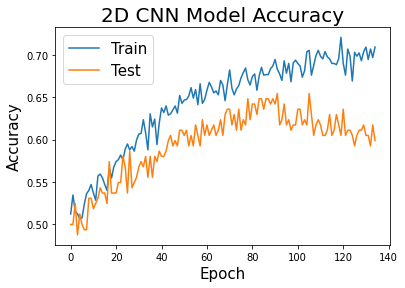

---BERT + 2D CNN + Hyperparameter Tuning Loss plot was saved.


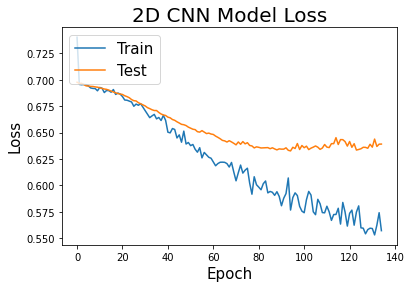

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 192, 5, 8)         136       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 96, 2, 8)         0         
 2D)                                                             
                                                                 
 dropout_8 (Dropout)         (None, 96, 2, 8)          0         
                                                                 
 conv2d_7 (Conv2D)           (None, 48, 1, 16)         528       
                                                                 
 dropout_9 (Dropout)         (None, 48, 1, 16)         0         
                                                                 
 flatten_4 (Flatten)         (None, 768)               0         
                                                      

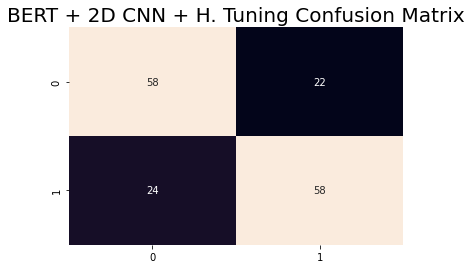

--- BERT + 2D CNN + Hyperparameter Tuning confusion matrix plot was saved.
AUC Score 0.7716463414634146


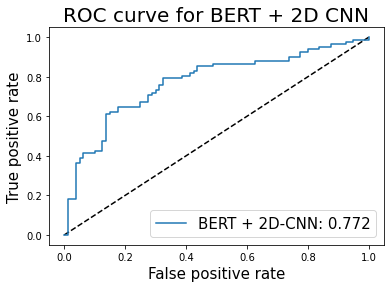

---BERT + 2D CNN + Hyperparameter Tuning ROC Curve plot was saved.


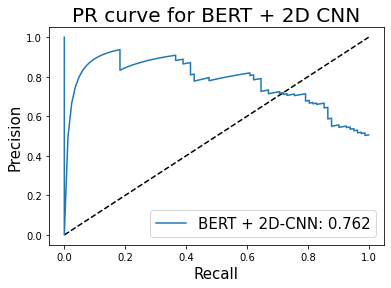

---BERT + 2D CNN + Hyperparameter Tuning PR Curve plot was saved.
----------------------------------------------


In [ ]:
plt.plot(history2_.history["accuracy"])
plt.plot(history2_.history["val_accuracy"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Accuracy", fontsize = 15)
plt.title("2D CNN Model Accuracy", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()


plt.plot(history2_.history["loss"])
plt.plot(history2_.history["val_loss"])
plt.xlabel("Epoch", fontsize = 15)
plt.ylabel("Loss", fontsize = 15)
plt.title("2D CNN Model Loss", fontsize = 20)
plt.legend(["Train", "Test"], loc="upper left",  prop={"size": 15})
plt.show()


print(model2.summary())

import seaborn as sns
from sklearn.metrics import confusion_matrix
cnn_predictions3 = model2.predict(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1)) 
bert2_probs = cnn_predictions3[:,1]
print(cnn_predictions3[:,1])    
cnn_predictions3 = np.argmax(cnn_predictions3, axis = 1)
print(cnn_predictions3)
confusion_matrix = confusion_matrix(ytest, cnn_predictions3)
sns.heatmap(confusion_matrix, annot = True, fmt = "d", cbar = False)
plt.title("BERT + 2D CNN + H. Tuning Confusion Matrix", fontsize = 20)
plt.show()


from sklearn.metrics import roc_curve
fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp, thresholds_keras = roc_curve(ytest, bert2_probs)

from sklearn.metrics import auc
auc_keras_bert_cnn2_hyp = auc(fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp)
print("AUC Score", auc_keras_bert_cnn2_hyp)

plt.clf()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras_bert_cnn2_hyp, tpr_keras_bert_cnn2_hyp, label="BERT + 2D-CNN: {:.3f}".format(auc_keras_bert_cnn2_hyp))
plt.xlabel("False positive rate", fontsize = 15)
plt.ylabel("True positive rate", fontsize = 15)
plt.title("ROC curve for BERT + 2D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


precision_bert2, recall_bert2, _ = precision_recall_curve(ytest, bert2_probs)
auc_precision_recall_bert2 = auc(recall_bert2, precision_bert2)

plt.clf()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(recall_bert2, precision_bert2, label="BERT + 2D-CNN: {:.3f}".format(auc_precision_recall_bert2))
plt.xlabel("Recall", fontsize = 15)
plt.ylabel("Precision", fontsize = 15)
plt.title("PR curve for BERT + 2D CNN", fontsize = 20)
plt.legend(loc="best",  prop={'size': 15})
plt.show()


print("----------------------------------------------")

# ViT

In [ ]:
pip install tensorflow-addons

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.2 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Activation, Conv1D, ZeroPadding1D, MaxPooling1D, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
import tensorflow as tf
from tensorflow import keras
from kerastuner import RandomSearch
from tensorflow.keras import utils
from sklearn.metrics import precision_recall_curve
from tensorflow.keras import layers
import tensorflow_addons as tfa
import tensorflow_addons as tfa
import pickle
import time
from tensorflow.keras.callbacks import TensorBoard
import keras_tuner as kt
from keras_tuner import RandomSearch


xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.20, random_state = 42)
xval, xtest, yval, ytest = train_test_split(xtest, ytest, test_size = 0.5)


num_classes = 2
input_shape = (768, 23, 1)

In [ ]:
learning_rate = 0.001         
weight_decay = 0.0001
batch_size = 200  
num_epochs = 50                                                                       
image_size = 16 
patch_size = 6  
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 12    
transformer_units = [projection_dim * 2, projection_dim, ] 
transformer_layers =  1     
mlp_head_units = [2048, 1024]  

In [ ]:
import keras

#####  Use data augmentation

data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(np.asarray(xtrain).reshape(len(np.asarray(xtrain)),768,23,1))

In [ ]:
#######  Implement multilayer perceptron (MLP)

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [ ]:
#######  Implement patch creation as a layer

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

In [ ]:
######  Implement the patch encoding layer

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [ ]:
# ################################ EDITTING VIT CODE #################################

######  Build the ViT model

def optimal_vit_classifier(hp):
    print("OK-1")
    inputs = layers.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    print(augmented.shape)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    print("OK-2")

  

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):                                                       
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads = num_heads, key_dim=projection_dim, dropout=0.1                            
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])
        print("OK-3")

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes, activation ="softmax")(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    print("OK-4")

    optimizer = tfa.optimizers.AdamW(learning_rate = learning_rate, weight_decay = weight_decay)   

    print("OK-5")
    
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[0.0005, 0.0001])),      
                  loss='categorical_crossentropy',
                  metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(), 
                           tf.keras.metrics.AUC(curve = "ROC"), tf.keras.metrics.AUC(curve = "PR")])
    
    return model

tuner_ch = kt.RandomSearch(optimal_vit_classifier,
                        objective="val_accuracy",                                                                 
                        max_trials = 15, directory = "output", project_name = "Crot_AfterHyperParameterTuning_ViT_homo")


OK-1
(None, 16, 16, 1)
OK-2
OK-3
OK-4
OK-5


In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0.0008, patience=100,  verbose=1, mode='min')

tuner_ch.search(np.asarray(xtrain.reshape(len(np.asarray(xtrain)),768,23,1)), utils.to_categorical(ytrain,2),
                validation_data = (np.asarray(xval.reshape(len(np.asarray(xval)),768,23,1)), utils.to_categorical(yval,2)), epochs = 50, callbacks = [stop_early])

In [ ]:
model3 = tuner_ch.get_best_models(num_models=1)[0]
history3_ = model3.fit(np.asarray(xtest).reshape(len(np.asarray(xtest)),768,23,1), utils.to_categorical(ytest,2), epochs = 800)

OK-1
(None, 16, 16, 1)
OK-2
OK-3
OK-4
OK-5
Epoch 1/800
6/6 [==============================] - 4s 23ms/step - loss: 0.6912 - accuracy: 0.5062 - precision: 0.5062 - recall: 0.5062 - auc: 0.5297 - auc_1: 0.5297 - auc_2: 0.5452
Epoch 2/800
6/6 [==============================] - 0s 24ms/step - loss: 0.6933 - accuracy: 0.5247 - precision: 0.5247 - recall: 0.5247 - auc: 0.5382 - auc_1: 0.5382 - auc_2: 0.5362
Epoch 3/800
6/6 [==============================] - 0s 22ms/step - loss: 0.6952 - accuracy: 0.5741 - precision: 0.5741 - recall: 0.5741 - auc: 0.5681 - auc_1: 0.5681 - auc_2: 0.5409
Epoch 4/800
6/6 [==============================] - 0s 24ms/step - loss: 0.6843 - accuracy: 0.5802 - precision: 0.5802 - recall: 0.5802 - auc: 0.6016 - auc_1: 0.6016 - auc_2: 0.5716
Epoch 5/800
6/6 [==============================] - 0s 23ms/step - loss: 0.6773 - accuracy: 0.5926 - precision: 0.5926 - recall: 0.5926 - auc: 0.5956 - auc_1: 0.5956 - auc_2: 0.5855
Epoch 6/800
6/6 [==============================] - 0